Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


,missing,percent
Cabin,687,77.1
Age,177,19.9
Embarked,2,0.2


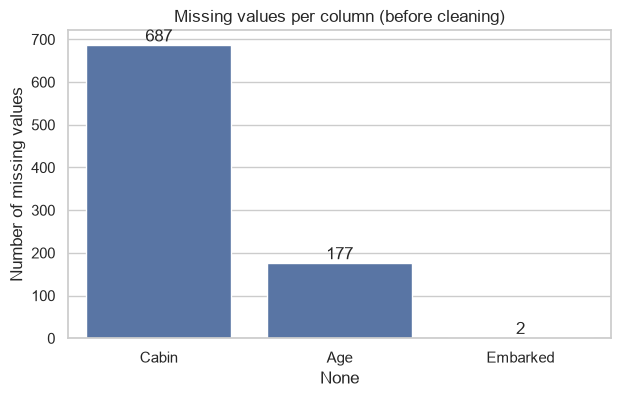

Dropped columns: ['Cabin']
Missing values after cleaning: 0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


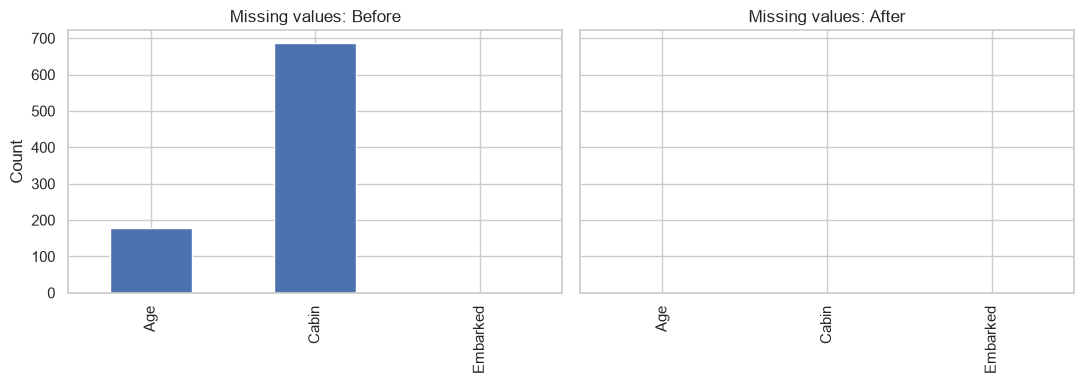

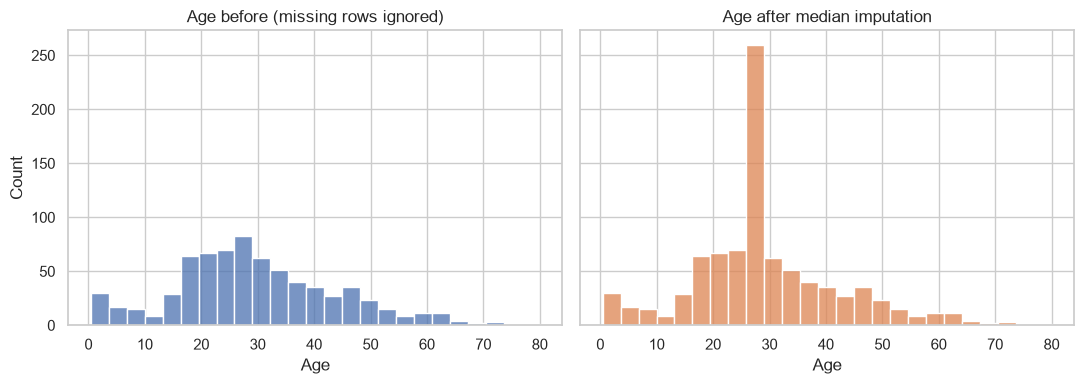

Mean   before / after: 29.7 / 29.36
Median before / after: 28.0 / 28.0


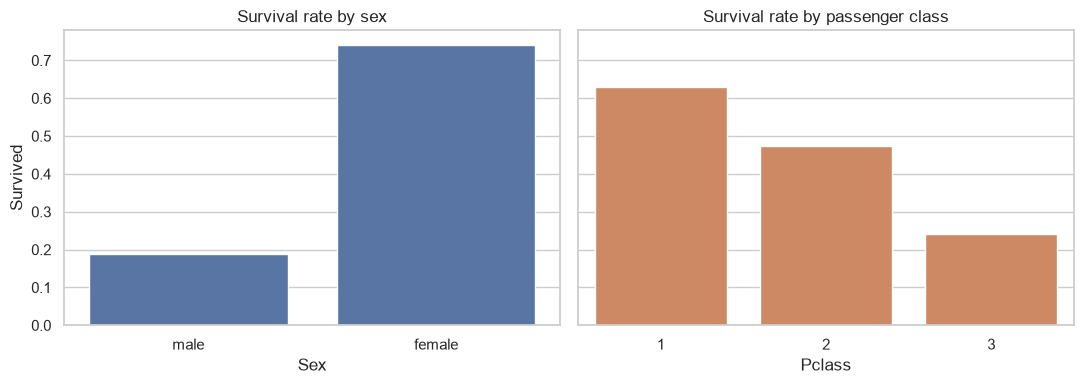

Pclass,1,2,3
Sex,,,
female,0.97,0.92,0.50
male,0.37,0.16,0.14


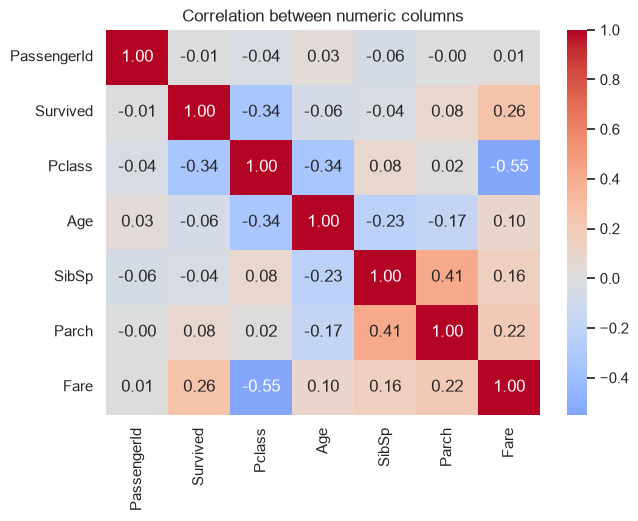

In [1]:
import sys
sys.path.append("..")  # so we can import from src/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from src.cleaner import impute

sns.set_theme(style="whitegrid")

# ---------------------------------------------------------------
# 1. Load the data
# ---------------------------------------------------------------
df = pd.read_csv("../data/raw/titanic.csv")
print("Shape:", df.shape)
display(df.head())
df.info()
display(df.describe())

# ---------------------------------------------------------------
# 2. Missing values (before cleaning)
# ---------------------------------------------------------------
missing = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(1)
summary = pd.DataFrame({"missing": missing, "percent": missing_pct})
display(summary[summary["missing"] > 0].sort_values("missing", ascending=False))

cols = missing[missing > 0].sort_values(ascending=False)
plt.figure(figsize=(7, 4))
ax = sns.barplot(x=cols.index, y=cols.values, color="#4C72B0")
ax.bar_label(ax.containers[0])
plt.title("Missing values per column (before cleaning)")
plt.ylabel("Number of missing values")
plt.show()

# ---------------------------------------------------------------
# 3. Clean the data
# ---------------------------------------------------------------
clean = impute(df)
print("Dropped columns:", sorted(set(df.columns) - set(clean.columns)))
print("Missing values after cleaning:", clean.isna().sum().sum())
display(clean.head())

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
before = df.isna().sum()
after = clean.isna().sum().reindex(df.columns, fill_value=0)
for ax, data, title in zip(axes, [before, after], ["Before", "After"]):
    data[data.index.isin(before[before > 0].index)].plot.bar(ax=ax, color="#4C72B0")
    ax.set_title(f"Missing values: {title}")
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# 4. Did imputation change the Age distribution?
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
sns.histplot(df["Age"].dropna(), bins=25, ax=axes[0], color="#4C72B0")
axes[0].set_title("Age before (missing rows ignored)")
sns.histplot(clean["Age"], bins=25, ax=axes[1], color="#DD8452")
axes[1].set_title("Age after median imputation")
plt.tight_layout()
plt.show()

print("Mean   before / after:", round(df["Age"].mean(), 2), "/", round(clean["Age"].mean(), 2))
print("Median before / after:", df["Age"].median(), "/", clean["Age"].median())

# ---------------------------------------------------------------
# 5. What affects survival?
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
sns.barplot(data=clean, x="Sex", y="Survived", ax=axes[0], color="#4C72B0", errorbar=None)
axes[0].set_title("Survival rate by sex")
sns.barplot(data=clean, x="Pclass", y="Survived", ax=axes[1], color="#DD8452", errorbar=None)
axes[1].set_title("Survival rate by passenger class")
plt.tight_layout()
plt.show()

display(clean.groupby(["Sex", "Pclass"])["Survived"].mean().unstack().round(2))

plt.figure(figsize=(7, 5))
sns.heatmap(clean.select_dtypes("number").corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation between numeric columns")
plt.show()